# The WKB approximation and tunneling in photodiodes

The WKB (semiclassical) approximation solves the Schrodinger equation where the potential varies slowly on
the scale of the de Broglie wavelength (Griffiths Ch. 9). Its most useful product is the **tunneling
probability** through a barrier a classical particle could never cross:
$$T\approx e^{-2\gamma},\qquad \gamma=\frac1\hbar\int_a^b\sqrt{2m\,[V(x)-E]}\;dx,$$
the integral running between the classical turning points. This one formula runs from alpha decay (Gamow)
to the scanning tunneling microscope -- and to the **dark current of a photodiode**.

In a reverse-biased photodiode the electric field tilts the bands into a **triangular barrier**, and WKB
through it gives the **Fowler-Nordheim / Zener** law $T\propto e^{-4\sqrt{2m}\,\Phi^{3/2}/(3\hbar eE)}$: a
field-driven **band-to-band tunneling** current that adds to the dark current and, at high field, drives
avalanche/Zener breakdown. (The same triangular barrier appeared as the confining well in the laser-gain
notebook -- tilt it the other way and it is a tunneling barrier.)

We verify WKB against the **exact** rectangular-barrier transmission, derive the triangular-barrier
(photodiode) case in SymPy, and compute Zener tunneling for a real semiconductor. Self-contained: NumPy,
SymPy, Pandas, Matplotlib. Units $\hbar=m=1$ for the model barriers, SI for the device.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The tunneling integral, tested on the rectangular barrier

For a rectangular barrier of height $V_0$ and width $L$ with $E<V_0$, the forbidden-region momentum is
imaginary, $\kappa=\sqrt{2m(V_0-E)}/\hbar$, and WKB gives simply $T_{\text{WKB}}=e^{-2\kappa L}$. The
**exact** transmission is
$$T=\left[1+\frac{V_0^2\sinh^2(\kappa L)}{4E(V_0-E)}\right]^{-1}.$$
For a thick/high barrier the exact result becomes $\dfrac{16E(V_0-E)}{V_0^2}\,e^{-2\kappa L}$: WKB captures
the **exponent exactly** and misses only the constant prefactor. We confirm the ratio approaches that
prefactor and that $\ln T$ has slope $-2\kappa$ in both.

In [2]:
V0, E = 4.0, 1.0                                              # hbar = m = 1
kappa = np.sqrt(2*(V0 - E))
T_exact = lambda L: 1/(1 + V0**2*np.sinh(kappa*L)**2/(4*E*(V0 - E)))
T_wkb   = lambda L: np.exp(-2*kappa*L)
prefactor = 16*E*(V0 - E)/V0**2                              # thick-barrier prefactor WKB omits

rows = []
for L in (2.0, 3.0, 4.0, 5.0):
    te, tw = T_exact(L), T_wkb(L)
    rows.append({"L": L, "exact T": f"{te:.3e}", "WKB T": f"{tw:.3e}", "ratio": round(te/tw, 4)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nexact/WKB ratio -> 16 E (V0-E)/V0^2 = {prefactor}  (WKB gets the exponent, misses the prefactor)")
assert abs(T_exact(5.0)/T_wkb(5.0) - prefactor) < 1e-3
# log-slope is -2 kappa for both
slope_exact = (np.log(T_exact(5.0)) - np.log(T_exact(4.0)))/1.0
assert abs(slope_exact - (-2*kappa)) < 1e-3
print(f"d(ln T)/dL = {slope_exact:.4f}  =  -2 kappa = {-2*kappa:.4f}  (WKB exponent is exact)")

  L   exact T     WKB T  ratio
2.0 1.667e-04 5.556e-05 2.9998
3.0 1.243e-06 4.142e-07 3.0000
4.0 9.262e-09 3.087e-09 3.0000
5.0 6.904e-11 2.301e-11 3.0000

exact/WKB ratio -> 16 E (V0-E)/V0^2 = 3.0  (WKB gets the exponent, misses the prefactor)
d(ln T)/dL = -4.8990  =  -2 kappa = -4.8990  (WKB exponent is exact)


## The triangular barrier: Fowler-Nordheim / Zener tunneling (SymPy)

A uniform field tilts a barrier to $V(x)=\Phi-Fx$ ($F=eE$ the electric force). Tunneling runs from $x=0$
to the turning point $x_t=\Phi/F$. SymPy evaluates the WKB integral:
$$\gamma=\frac1\hbar\int_0^{\Phi/F}\sqrt{2m(\Phi-Fx)}\,dx=\frac{2\sqrt{2m}\,\Phi^{3/2}}{3\hbar F},\qquad
T=e^{-2\gamma}=\exp\!\left[-\frac{4\sqrt{2m}\,\Phi^{3/2}}{3\hbar eE}\right].$$
This is the **Fowler-Nordheim law** (field emission) and, for band-to-band tunneling across a reverse-biased
junction with $\Phi\sim E_g$, the **Zener** tunneling that feeds a photodiode's dark current. Note the
signature $\ln T\propto-1/E$: the current is exponentially sensitive to the field.

In [3]:
m, hbar, Phi, F, x = sp.symbols('m hbar Phi F x', positive=True)
gamma = sp.simplify(sp.integrate(sp.sqrt(2*m*(Phi - F*x)), (x, 0, Phi/F))/hbar)
assert sp.simplify(gamma - 2*sp.sqrt(2*m)*Phi**sp.Rational(3,2)/(3*hbar*F)) == 0
T_tri = sp.exp(-2*gamma)
print("WKB exponent gamma =", gamma)
print("triangular-barrier transmission  T = exp(-2 gamma) = exp[-4 sqrt(2m) Phi^{3/2} / (3 hbar e E)]")
print("  -> Fowler-Nordheim / Zener band-to-band tunneling; ln T is proportional to -1/E")

WKB exponent gamma = 2*sqrt(2)*Phi**(3/2)*sqrt(m)/(3*F*hbar)
triangular-barrier transmission  T = exp(-2 gamma) = exp[-4 sqrt(2m) Phi^{3/2} / (3 hbar e E)]
  -> Fowler-Nordheim / Zener band-to-band tunneling; ln T is proportional to -1/E


## Zener tunneling in a photodiode: dark current vs reverse-bias field

Put in real numbers for a silicon-like junction: barrier $\Phi\approx E_g=1.12$ eV, tunneling effective
mass $m^*\approx0.2\,m_e$. Sweep the depletion-region field $E$. The transmission is negligible until the
field reaches $\sim10^8\,\mathrm{V/m}$, then rises by tens of orders of magnitude over a narrow range --
exactly the steep dark-current turn-on that marks the onset of **Zener/avalanche breakdown** and limits how
far a photodiode can be reverse-biased.

In [4]:
Eg = 1.12*C.E                                                # barrier height (J)
mstar = 0.2*C.M_E                                            # tunneling effective mass
def zener_T(field):                                         # field in V/m
    expo = 4*np.sqrt(2*mstar)*Eg**1.5/(3*C.HBAR*C.E*field)
    return np.exp(-expo), expo

rows = []
for field in (3e7, 1e8, 2e8, 3e8, 5e8):
    T, expo = zener_T(field)
    rows.append({"field [V/m]": f"{field:.0e}", "FN exponent": round(expo, 2), "tunneling T": f"{T:.2e}"})
print(pd.DataFrame(rows).to_string(index=False))
print("\nT jumps from ~1e-53 to ~1e-3 between 3e7 and 5e8 V/m -> steep dark-current / breakdown onset")
assert zener_T(3e8)[0] > zener_T(3e7)[0]*1e40                # tunneling rises enormously with field

field [V/m]  FN exponent tunneling T
      3e+07       120.70    3.82e-53
      1e+08        36.21    1.88e-16
      2e+08        18.10    1.37e-08
      3e+08        12.07    5.73e-06
      5e+08         7.24    7.16e-04

T jumps from ~1e-53 to ~1e-3 between 3e7 and 5e8 V/m -> steep dark-current / breakdown onset


## Plots

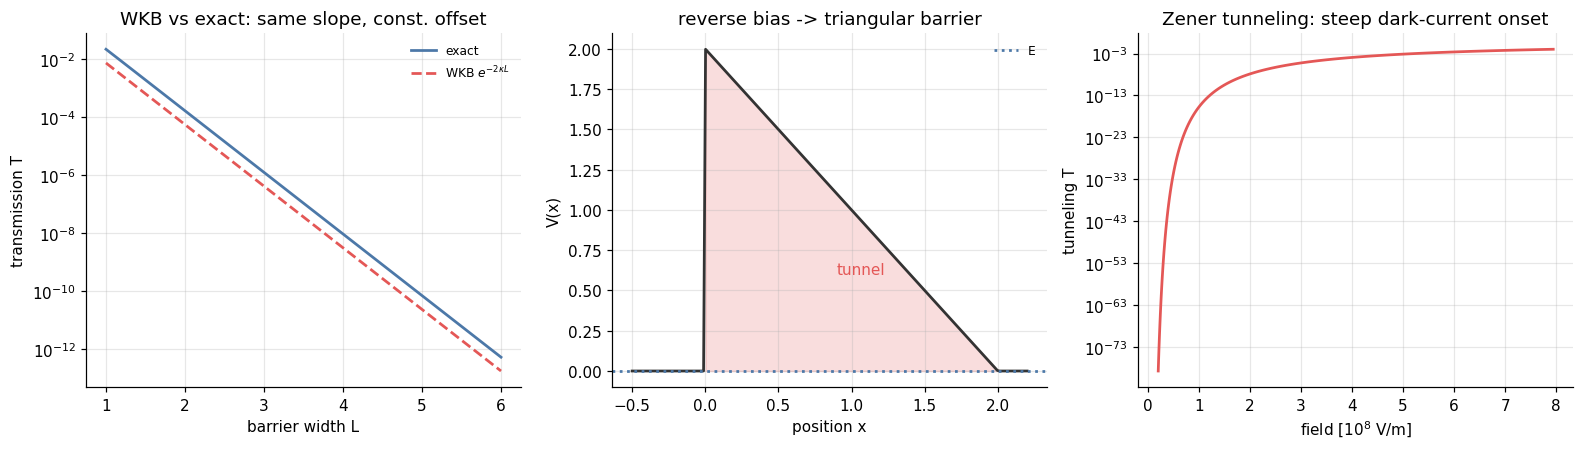

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
# (1) rectangular barrier: exact vs WKB transmission
Ls = np.linspace(1, 6, 100)
ax[0].semilogy(Ls, [T_exact(L) for L in Ls], color="#4C78A8", label="exact")
ax[0].semilogy(Ls, [T_wkb(L) for L in Ls], "--", color="#E45756", label="WKB $e^{-2\\kappa L}$")
ax[0].set_xlabel("barrier width L"); ax[0].set_ylabel("transmission T")
ax[0].set_title("WKB vs exact: same slope, const. offset"); ax[0].legend(fontsize=8)
# (2) the triangular barrier picture
xg = np.linspace(-0.5, 2.2, 200); Phi_v, F_v, E_v = 2.0, 1.0, 0.0
Vg = np.where(xg < 0, 0.0, np.where(xg < Phi_v/F_v, Phi_v - F_v*xg, 0.0))
ax[1].plot(xg, Vg, color="#333"); ax[1].axhline(E_v, ls=":", color="#4C78A8", label="E")
ax[1].fill_between(xg, E_v, Vg, where=(Vg > E_v), color="#E45756", alpha=0.2)
ax[1].annotate("tunnel", xy=(0.9, 0.6), color="#E45756")
ax[1].set_xlabel("position x"); ax[1].set_ylabel("V(x)")
ax[1].set_title("reverse bias -> triangular barrier"); ax[1].legend(fontsize=8)
# (3) Zener transmission vs reverse-bias field (dark-current turn-on)
fields = np.logspace(7.3, 8.9, 100)
Ts = np.array([zener_T(f)[0] for f in fields])
ax[2].semilogy(fields/1e8, Ts, color="#E45756")
ax[2].set_xlabel("field [10$^8$ V/m]"); ax[2].set_ylabel("tunneling T")
ax[2].set_title("Zener tunneling: steep dark-current onset")
plt.tight_layout(); plt.show()

## Exercises

1. **Gamow / alpha decay.** For the Coulomb barrier $V(r)=\tfrac{2Ze^2}{4\pi\varepsilon_0 r}$ outside the
   nucleus, evaluate the WKB integral and reproduce the Geiger-Nuttall relation between half-life and
   decay energy -- the original triumph of tunneling theory.
2. **STM.** With a vacuum barrier of work function $\Phi\approx4$ eV, show the tunneling current changes by
   a decade for every ~1 Angstrom change in tip-sample gap -- the atomic resolution of the microscope.
3. **Resonant-tunneling diode.** Put two barriers in series with a well between; find the energies where
   $T\to1$ (resonances) and relate them to the well's quasi-bound states.
4. **Temperature vs field.** Compare Zener (field) tunneling current with thermally activated dark current
   $\propto e^{-E_g/2k_BT}$; find the field/temperature boundary where tunneling dominates.

## Summary

- WKB gives the tunneling probability $T\approx e^{-2\gamma}$, $\gamma=\tfrac1\hbar\int\sqrt{2m(V-E)}\,dx$
  between turning points. Against the **exact** rectangular barrier it reproduces the exponent exactly and
  misses only the prefactor $16E(V_0-E)/V_0^2$ (verified).
- The **triangular barrier** (reverse-biased junction) gives, in SymPy, the **Fowler-Nordheim / Zener** law
  $T=\exp[-4\sqrt{2m}\,\Phi^{3/2}/(3\hbar eE)]$ with $\ln T\propto-1/E$.
- For a silicon-like photodiode this **band-to-band tunneling** is negligible until $E\sim10^8\,$V/m, then
  rises by tens of orders of magnitude -- the dark-current turn-on and the onset of Zener/avalanche
  breakdown that bounds the usable reverse bias.

Subject-verb-object: the field tilts the barrier; the WKB integral sets the exponent; the tunneling current
turns on steeply; the dark current bounds the bias.